In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [6]:
df = pd.read_csv("KNN-HR-Employee-Attrition.csv")

print(df.head())
print("-------------")
print(df.columns)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [7]:
# Clean coulmn names
df.columns = df.columns.str.strip()

In [8]:
# Drop unnecessary ID columns if present
df.drop(columns = ["EmployeeNumber", "EmployeeCount","Over18"],
       errors = 'ignore', inplace = True)

In [9]:
# Convert Attrition (Yes/No → 1/0)

df["Attrition"] = df["Attrition"].map({"Yes":1, "No":0})

In [10]:
# Convert all categorical columns

df = pd.get_dummies(df, drop_first = True)

In [11]:
X = df.drop("Attrition", axis = 1)
y = df["Attrition"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [15]:
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [16]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8809523809523809


In [18]:
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Confusion Matrix :
 [[252   3]
 [ 32   7]]


In [19]:
print("Classification Report :\n", classification_report(y_test, y_pred))

Classification Report :
               precision    recall  f1-score   support

           0       0.89      0.99      0.94       255
           1       0.70      0.18      0.29        39

    accuracy                           0.88       294
   macro avg       0.79      0.58      0.61       294
weighted avg       0.86      0.88      0.85       294



In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score :", roc_auc)

AUC Score : 0.6837104072398189


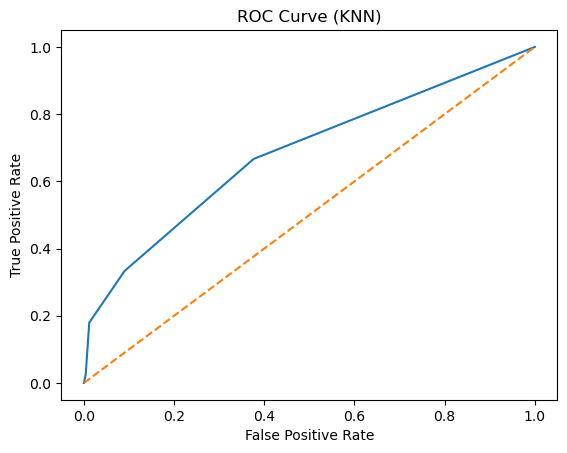

In [22]:
plt.figure()
plt.plot(fpr, tpr, label = "AUC = " + str(round(roc_auc, 3)))

# fpr → False Positive Rate
# tpr → True Positive Rate (Recall)
# label = "AUC = " + str(round(roc_auc, 3))

# 🔹 roc_auc
# Area Under Curve value (0 to 1)

# 🔹 round(roc_auc, 3)
# Rounds to 3 decimal places
# Example:
# 0.845678 → 0.846

# 🔹 Final Label:
# "AUC = 0.846"

plt.plot([0,1], [0,1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve (KNN)")

plt.show()

In [25]:
k_values = range(1,21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    

C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

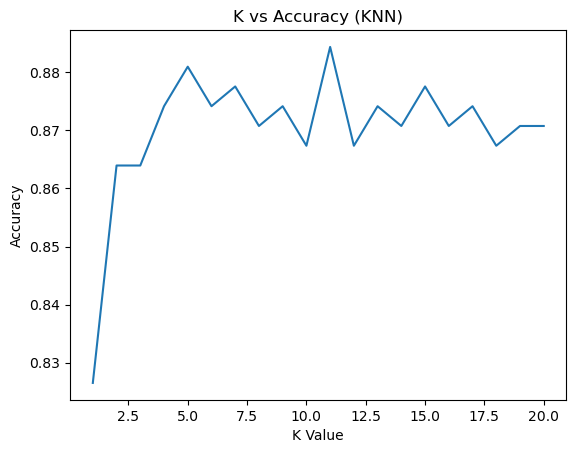

In [26]:
plt.figure()
plt.plot(k_values, accuracies)

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("K vs Accuracy (KNN)")

plt.show()